## 1. Exploratory Data Analysis

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('phishing_dataset_200k.csv')
print("Shape:", df.shape)
print(df.info())

Shape: (208549, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208549 entries, 0 to 208548
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   url_length          208549 non-null  int64 
 1   dot_count           208549 non-null  int64 
 2   has_at_symbol       208549 non-null  int64 
 3   has_hyphen          208549 non-null  int64 
 4   subdomain_count     208549 non-null  int64 
 5   is_https            208549 non-null  int64 
 6   path_length         208549 non-null  int64 
 7   query_length        208549 non-null  int64 
 8   has_ip_address      208549 non-null  int64 
 9   special_char_count  208549 non-null  int64 
 10  double_slash_count  208549 non-null  int64 
 11  digit_count         208549 non-null  int64 
 12  url                 208549 non-null  object
 13  label               208549 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 22.3+ MB
None


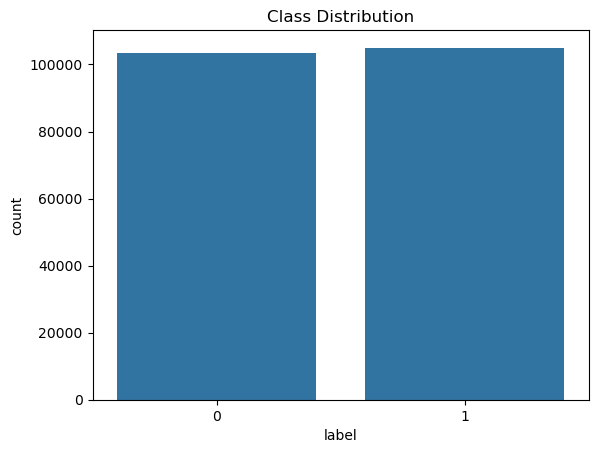

In [5]:
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.show()

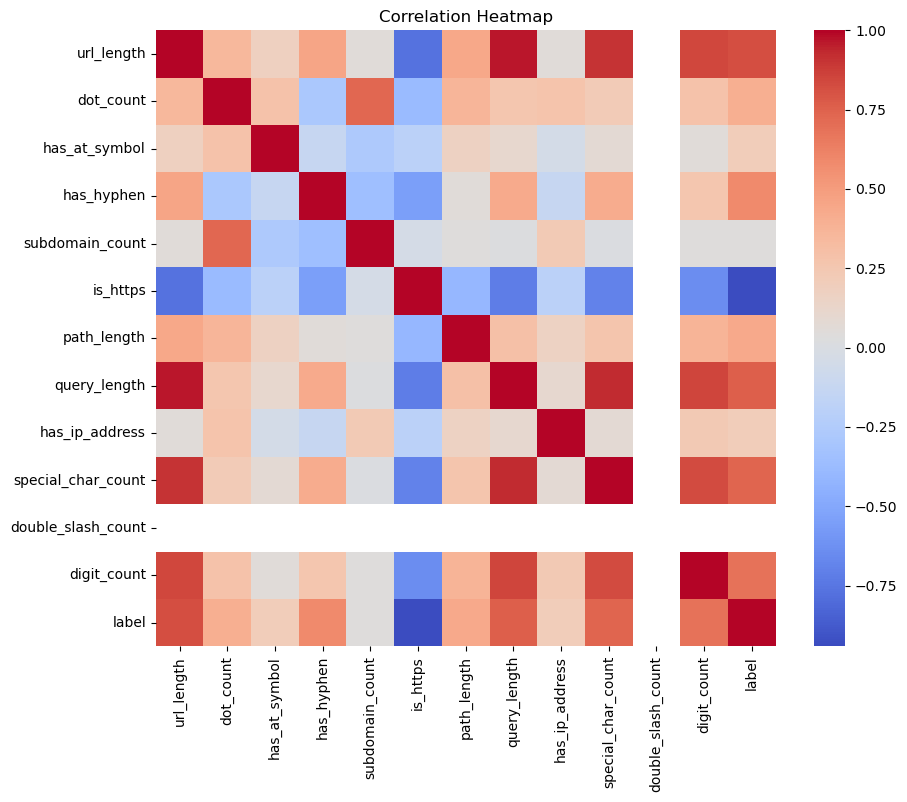

In [7]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 2. Data Preprocessing

In [11]:
print(df.columns)

Index(['url_length', 'dot_count', 'has_at_symbol', 'has_hyphen',
       'subdomain_count', 'is_https', 'path_length', 'query_length',
       'has_ip_address', 'special_char_count', 'double_slash_count',
       'digit_count', 'url', 'label'],
      dtype='object')


In [13]:
df = df.dropna()

X = df.drop('label', axis=1)
y = df['label']

## 3. Feature Selection & Importance

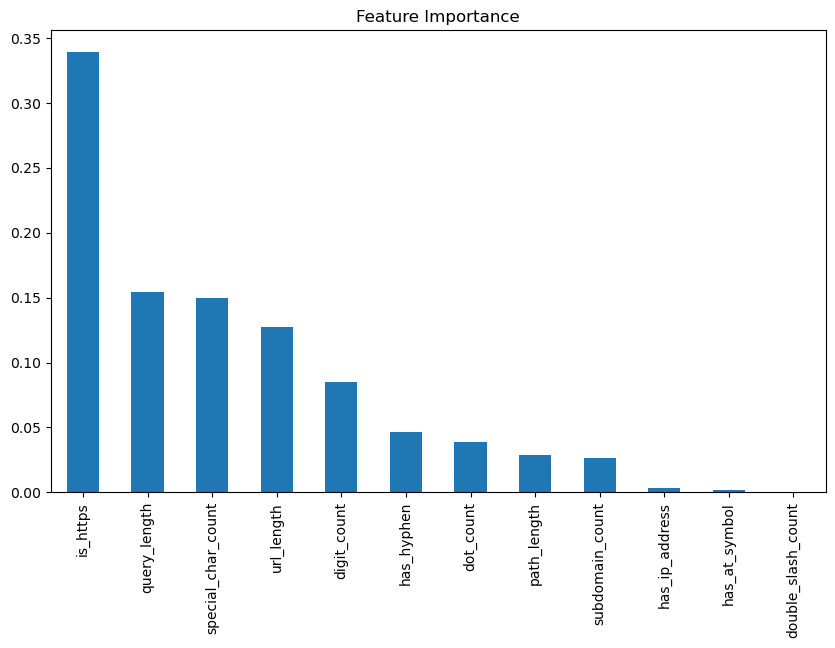

In [16]:
from sklearn.ensemble import RandomForestClassifier

# keep only numeric data
X = X.select_dtypes(include=['number'])

# remove NaN
X = X.fillna(0)

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X, y)

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

## 4. Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 5. Model Training

In [18]:
model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 6. Model Evaluation

Accuracy: 0.9997362742747543
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20870
           1       1.00      1.00      1.00     20840

    accuracy                           1.00     41710
   macro avg       1.00      1.00      1.00     41710
weighted avg       1.00      1.00      1.00     41710



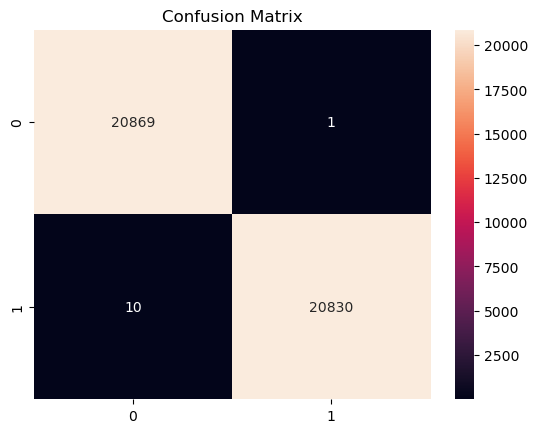

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

#ROC Curve

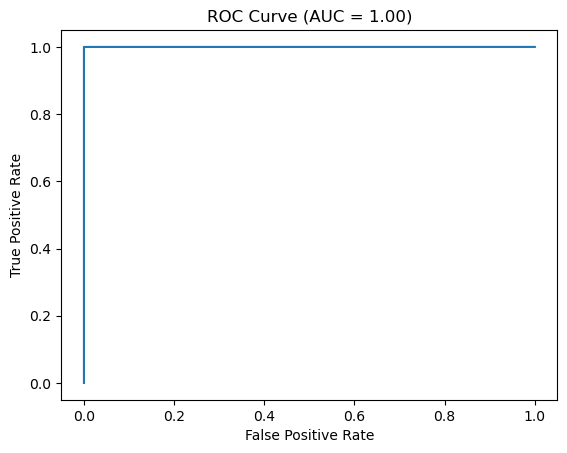

In [20]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.title("ROC Curve (AUC = %0.2f)" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

#Accuracy & Metrics

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Other Metrics
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Full Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9997362742747543
Precision: 0.9999519946233978
Recall: 0.9995201535508638
F1 Score: 0.9997360274531448

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20870
           1       1.00      1.00      1.00     20840

    accuracy                           1.00     41710
   macro avg       1.00      1.00      1.00     41710
weighted avg       1.00      1.00      1.00     41710



#Confusion Matrix

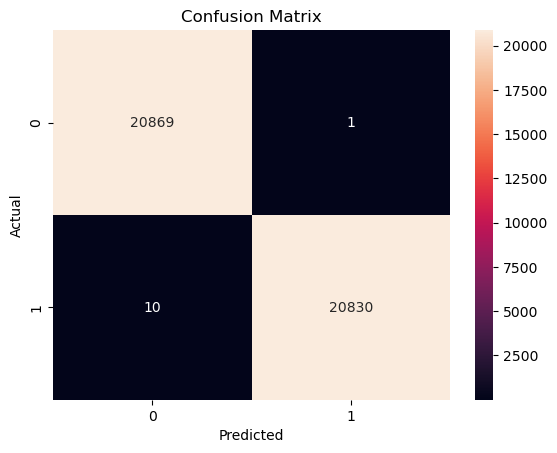

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 8. Save Model

In [24]:
import joblib
joblib.dump(model, "phishing.pkl")

['phishing.pkl']